   # ONLINE SHOPPING INTENTION
## Machine Learning And Deep Learning
##### Project by Dorcas Namazzi
###### 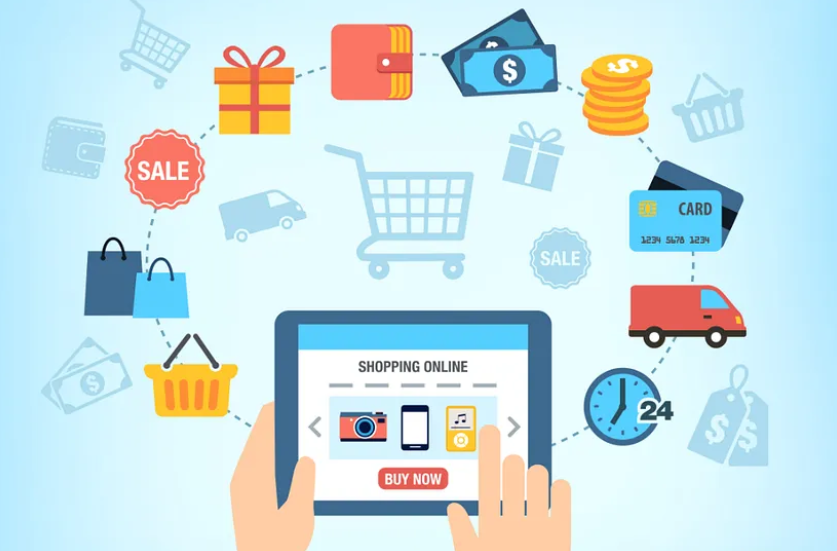

### INTRODUCTION:
This is a project about an online shopping assessment and shopping intent and Web site abandonment likelihood.
I will delve into the onlineshopping data and come up with models that can be used for prediction. The target is binary and 
it is based on revenue. We need to understand if the visit to the site, will end in a purchase which is revenue or not.

### Methodology
I will carry out the following tasks:
1. check for missing values
2. Handle duplicate values
3. Detect and remove outliers
4. Data scaling
5. Data encoding
6. Dimension Reduction.

### Objectives
The objective will include building classification models to predict the shoppers's intention. models like Logistic regresion, KNN, and random forests will be passed through a grid search to choose the best parametrs for the models.

## Conclusion
  In conclusion However, these models will be evaluated on the necesary metrics steming from accuracy, precision, recall, AUC or even confusion matrix depending on which one is more appropriate given the circumstances.


  ### Data dictionary
  
  The data consists of 18 features of which 8 are categorical and 10 are numerical. The data also contains of 12205 instances before data cleaning.  
  
##### Categorical Features:
1.Operating System - Different types of operating systems (e.g., Windows, macOS, Linux).

2.Browser - Different types of browsers (e.g., Chrome, Firefox, Safari).

3.Region - Different geographic regions (e.g., North America, Europe).

4.Traffic Type - Different types of traffic sources (e.g., direct, referral, organic).

5.Visitor Type - Whether the visitor is returning or new.

6.Weekend - A Boolean value indicating whether the visit is on a weekend.

7.Month - The month of the year (e.g., January, February).

8.Revenue - This is the target valuable

##### Numerical Features:
1.Administrative - Number of administrative pages visited.

2.Administrative Duration - Total time spent on administrative pages.

3.Informational - Number of informational pages visited.

4.Informational Duration - Total time spent on informational pages.

5.Product Related - Number of product-related pages visited.

6.Product Related Duration - Total time spent on product-related pages.

7.Bounce Rate - Percentage of visitors who leave the site without triggering further requests.

8.Exit Rate - Percentage of pageviews where the page was the last in the session.

9.Page Value - Average value for a page visited before completing an e-commerce transaction.

10.Special Day - Indicates the closeness of the visit to a special day, with values ranging from 0 to 1. The value of this attribute is determined by considering the dynamics of e-commerce such as the duration between the order date and delivery date.

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.options.display.float_format = "{:.2f}".format

# Q1 Import the database

In [3]:
online= pd.read_csv('online_shoppers_intention.csv')

# Qn 2 Show the first 5 and last 5 records

In [4]:
online

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.00,0,0.00,2,2.67,0.05,0.14,0.00,0.00,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.00,0,0.00,53,1783.79,0.01,0.03,12.24,0.00,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.00,0,0.00,5,465.75,0.00,0.02,0.00,0.00,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.00,0,0.00,6,184.25,0.08,0.09,0.00,0.00,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.00,0,0.00,15,346.00,0.00,0.02,0.00,0.00,Nov,2,2,3,11,Returning_Visitor,False,False


# Qn.3 Check and note the data types

In [5]:
online.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

###### From above we can see the different data types, we have int64,float64, object and boolean.

# Qn4. Define number of missing entries per variable

In [6]:
missing_value = pd.DataFrame(online.isna().sum()).reset_index()
missing_value = missing_value.rename(columns = {'index': 'column', 0: "no_of_missing_values"})
missing_value

,column,no_of_missing_values
0,Administrative,0
1,Administrative_Duration,0
2,Informational,0
3,Informational_Duration,0
4,ProductRelated,0
5,ProductRelated_Duration,0
6,BounceRates,0
7,ExitRates,0
8,PageValues,0
9,SpecialDay,0


# Qn5. Identify and count duplicate records.

In [5]:
online.duplicated().sum()

125

###### Removing duplicate values


In [6]:
online_original= online.copy()

In [7]:
no_dups= online.drop_duplicates()

In [8]:
online=no_dups

In [9]:
online.duplicated().sum()

0

In [12]:
online.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.00,0,0.00,2,2.67,0.05,0.14,0.00,0.00,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00,Feb,3,3,1,4,Returning_Visitor,True,False


# Qn6 Conducting univariate analysis on all variables creating appropraite visualisations

In [13]:
online.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12

In [14]:
online.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

## Categorical Variables

#### Revenue Variable

In [16]:
online['Revenue'].value_counts(normalize=True)*100

Revenue
False   84.37
True    15.63
Name: proportion, dtype: float64

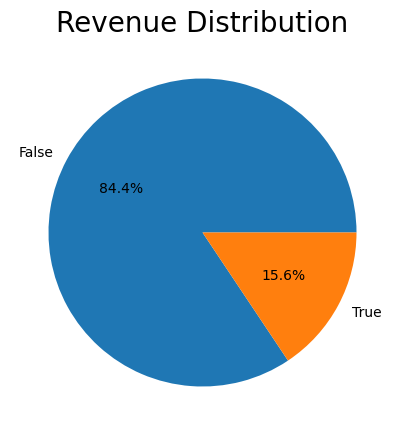

In [189]:
stat=online.Revenue.value_counts()
plt.rcParams["figure.figsize"] = (5,5)
plt.pie(stat, labels= stat.index, autopct='%.1f%%')
plt.title("Revenue Distribution",fontdict={"fontsize": 20})
plt.show() 

#### Month 

In [140]:
online['Month'].value_counts()

Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64

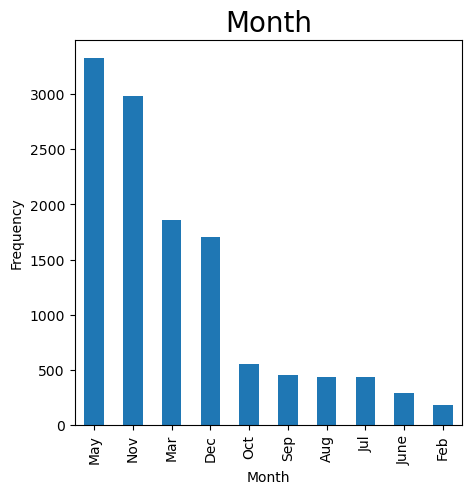

In [142]:
online.Month.value_counts().plot(kind='bar')
plt.title("Month",fontdict={"fontsize": 20})
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.show()

As seen above, May has the highest number of online shoppers compared to the rest of the months.

#### OperatingSystems

In [143]:
online.OperatingSystems.value_counts()

OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64

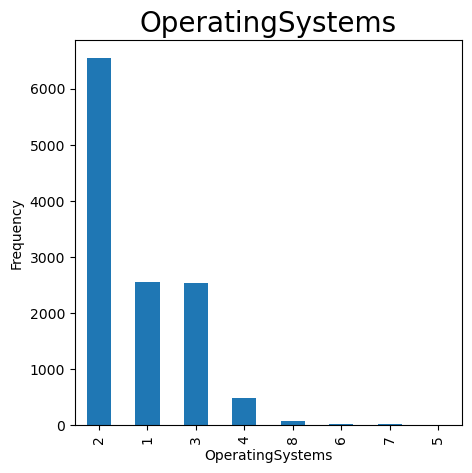

In [144]:
online.OperatingSystems.value_counts().plot(kind='bar')
plt.title("OperatingSystems",fontdict={"fontsize": 20})
plt.xlabel('OperatingSystems')
plt.ylabel('Frequency')
plt.show()

The above bar shows the distribution of the operating systems, operating sys 2 has the highest number of online presence.

#### Browser

In [145]:
online.Browser.value_counts()

Browser
2     7883
1     2427
4      731
5      465
6      174
10     163
8      135
3      105
13      56
7       49
12      10
11       6
9        1
Name: count, dtype: int64

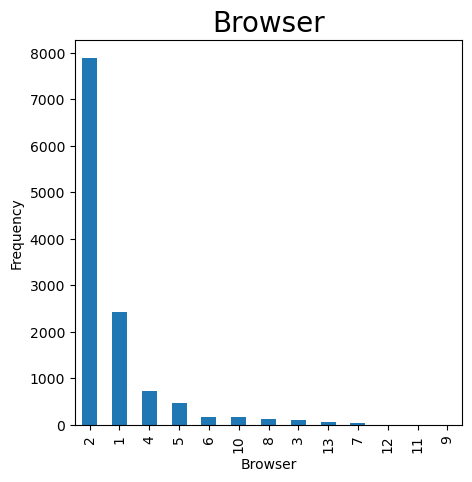

In [146]:
online.Browser.value_counts().plot(kind='bar')
plt.title("Browser",fontdict={"fontsize": 20})
plt.xlabel('Browser')
plt.ylabel('Frequency')
plt.show()

In [ ]:
The above shows the online shopers using the different browsers.

#### Region        

In [147]:
online.Region.value_counts()

Region
1    4714
3    2379
4    1171
2    1128
6     801
7     758
9     505
8     431
5     318
Name: count, dtype: int64

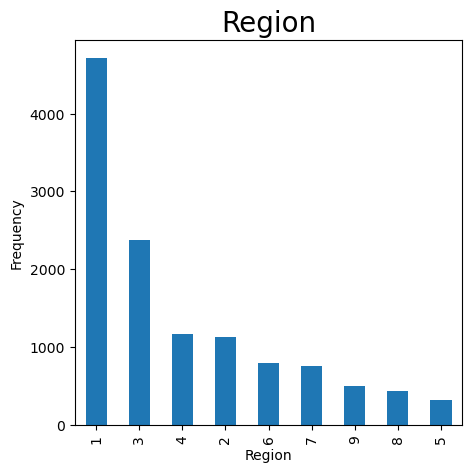

In [148]:
online.Region.value_counts().plot(kind='bar')
plt.title("Region",fontdict={"fontsize": 20})
plt.xlabel('Region')
plt.ylabel('Frequency')
plt.show()

The bar represents the regions of online shoppers. region 1 has the highest number of shoppers.

#### TrafficType 

In [198]:
online.TrafficType .value_counts()

TrafficType
2     3911
1     2388
3     2013
4     1066
13     728
10     450
6      443
8      343
5      260
11     247
20     193
9       41
7       40
15      37
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

In [11]:
def categorize(value):
    if value in [1,2,3,4,5]:
        return value
    else:
        return 'other'  

# Apply the function to create a new column 'view_merged'
online['Traffic_Type'] = online['TrafficType'].apply(categorize)


In [12]:
online.head(1)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Traffic_Type
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,1,1,1,1,Returning_Visitor,False,False,1


In [13]:
online.drop(['TrafficType'],axis=1, inplace= True)

In [19]:
online.head(1)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,VisitorType,Weekend,Revenue,Traffic_Type
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,1,1,1,Returning_Visitor,False,False,1


In [19]:
online.Traffic_Type.value_counts()

Traffic_Type
2        3911
other    2567
1        2388
3        2013
4        1066
5         260
Name: count, dtype: int64

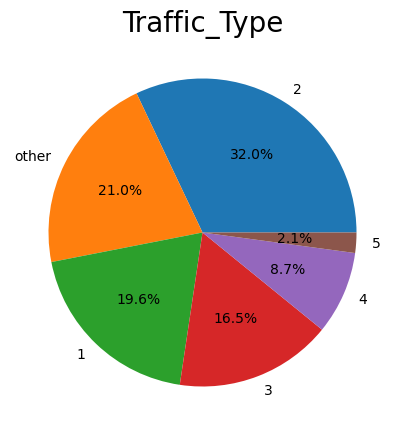

In [202]:
stat=online.Traffic_Type.value_counts()
plt.rcParams["figure.figsize"] = (5,5)
plt.pie(stat, labels= stat.index, autopct='%.1f%%')
plt.title("Traffic_Type",fontdict={"fontsize": 20})
plt.show() 

The above chart shows the traffic types, 2 is the highest, followed by combined value of others,
then 1,3,5 and 4 respectively

#### visitorType 

In [203]:
online.VisitorType.value_counts()

VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

The types of visitors are seen as above with returning vistors having the highest number
New visitors are next in line then others have the least.

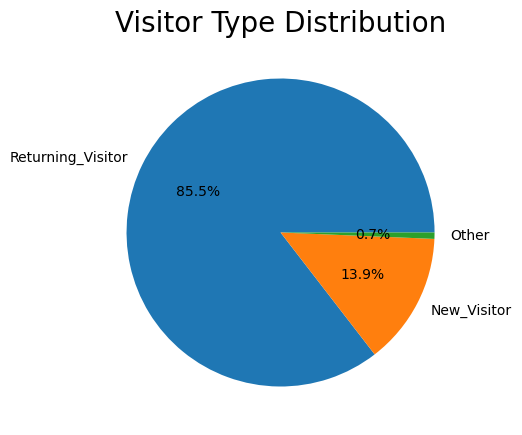

In [204]:
stat=online.VisitorType.value_counts()
plt.rcParams["figure.figsize"] = (5,5)
plt.pie(stat, labels= stat.index, autopct='%.1f%%')
plt.title("Visitor Type Distribution",fontdict={"fontsize": 20})
plt.show() 

Returning visitors have the highest percentage at 85%, New visitors have 13.9% and others have 0.7%

#### Weekend

In [160]:
online. Weekend.value_counts()

Weekend
False    9346
True     2859
Name: count, dtype: int64

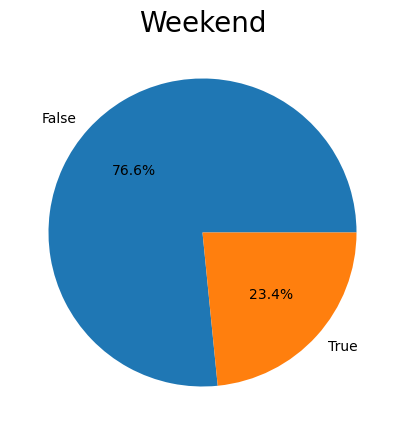

In [161]:
stat=online.Weekend.value_counts()
plt.rcParams["figure.figsize"] = (5,5)
plt.pie(stat, labels= stat.index, autopct='%.1f%%')
plt.title("Weekend",fontdict={"fontsize": 20})
plt.show() 

The above shows weekend shows as True and those who dont shop over the weekend as false.

## Numerical Variables
##### Administrative

In [14]:
from scipy import stats
from scipy.stats import norm

In [206]:
online.Administrative.describe()

count   12205.00
mean        2.34
std         3.33
min         0.00
25%         0.00
50%         1.00
75%         4.00
max        27.00
Name: Administrative, dtype: float64

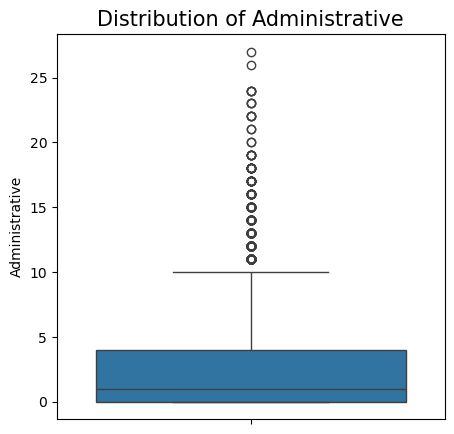

In [219]:
sns.boxplot(online.Administrative)
plt.title("Distribution of Administrative", y=1, fontdict={"fontsize": 15})
plt.show()



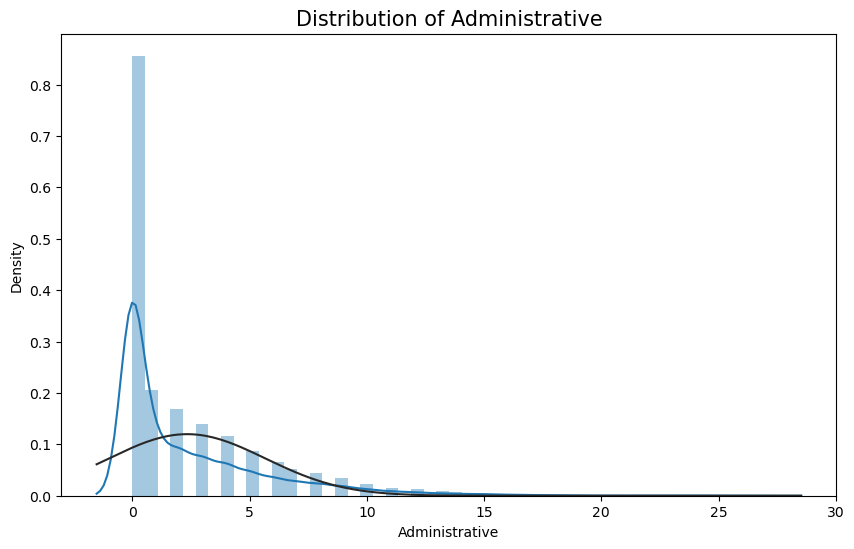

In [586]:
sns.distplot(online.Administrative, fit= norm)
plt.title("Distribution of Administrative", y=1, fontdict={"fontsize": 15})
plt.show()

from the above, we can see that the feature administrative is not normally distributed,
the boxplot shows there are outliers.
We will however go ahead and check the pvalue to prove the normality.
H0 Data is normally distributed
H1 Data is not normally distributed

In [226]:
stats.normaltest(online.Administrative)

NormaltestResult(statistic=4760.192487253146, pvalue=0.0)

From the above, we will reject the null hypothesis and conclude that the data is not normally distributed.

#### Administrative_Duration

In [228]:
online.Administrative_Duration.describe()

count   12205.00
mean       81.65
std       177.49
min         0.00
25%         0.00
50%         9.00
75%        94.70
max      3398.75
Name: Administrative_Duration, dtype: float64

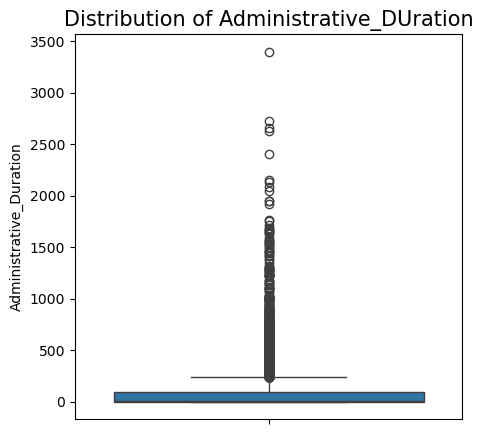

In [229]:
sns.boxplot(online.Administrative_Duration)
plt.title("Distribution of Administrative_DUration", y=1, fontdict={"fontsize": 15})
plt.show()

The above boxplot shows no normal distribution and alot of outliers

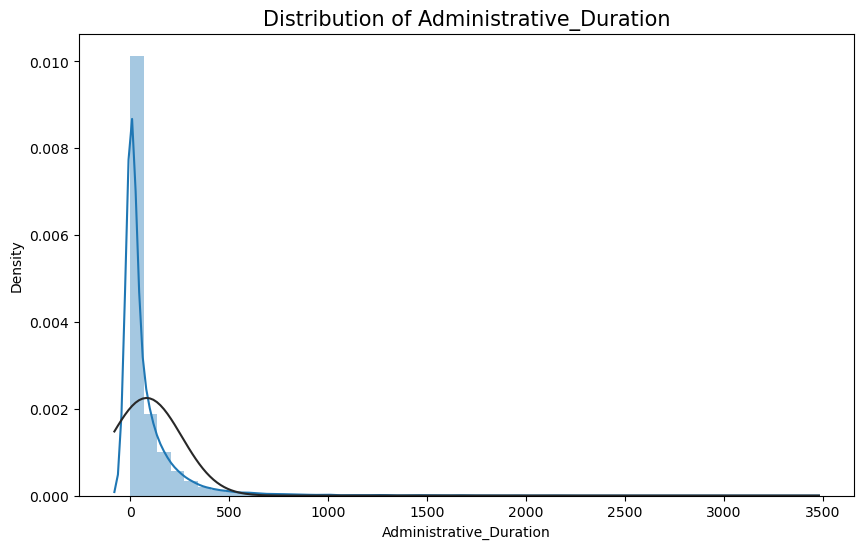

In [587]:
sns.distplot(online.Administrative_Duration, fit= norm)
plt.title("Distribution of Administrative_Duration", y=1, fontdict={"fontsize": 15})
plt.show()

The data is not normally distributed. we will still go ahead and check the pvalue

In [234]:
stats.normaltest(online.Administrative_Duration)

NormaltestResult(statistic=13407.09534492674, pvalue=0.0)

H0  Data is normally distributed
H1 Data is not normally distributed

From the above, the pvalue is less than 5% so we reject the null hypothesis and conclude that Administrative duration is not normally distributed.

#### Informational

In [235]:
online.Informational.describe()

count   12205.00
mean        0.51
std         1.28
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        24.00
Name: Informational, dtype: float64

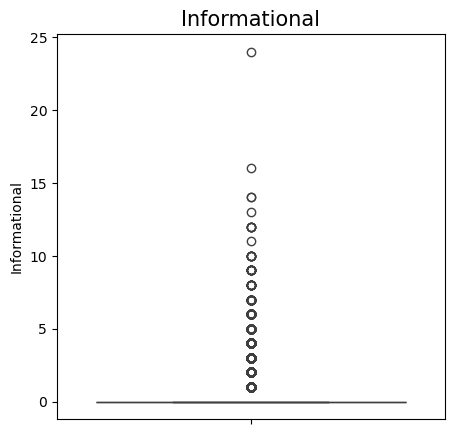

In [240]:
sns.boxplot(online.Informational)
plt.title("Informational", y=1, fontdict={"fontsize": 15})
plt.show()

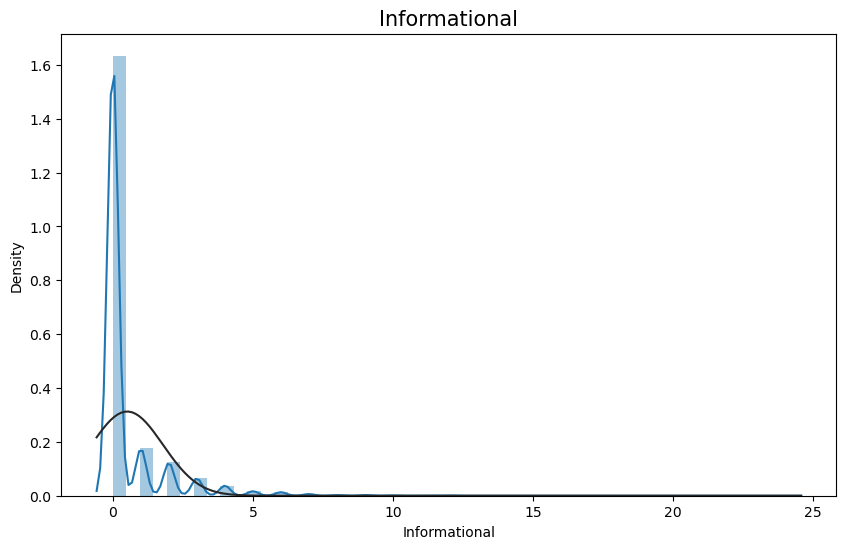

In [588]:
sns.distplot(online.Informational, fit= norm)
plt.title("Informational", y=1, fontdict={"fontsize": 15})
plt.show()

The above plot also indicates that informational is not normally distributed it, has many peaks.
so we proceed to check the pvalue.
H0 that informational is normally distributed
H1 that its not normally distributed.

In [242]:
stats.normaltest(online.Informational)

NormaltestResult(statistic=10490.814967665416, pvalue=0.0)

The pvalue is less than 5% so we reject the null hypothesis and conclude that informational is not normally distributed.

#### Informational_Duration

In [243]:
online.Informational_Duration.describe()

count   12205.00
mean       34.83
std       141.42
min         0.00
25%         0.00
50%         0.00
75%         0.00
max      2549.38
Name: Informational_Duration, dtype: float64

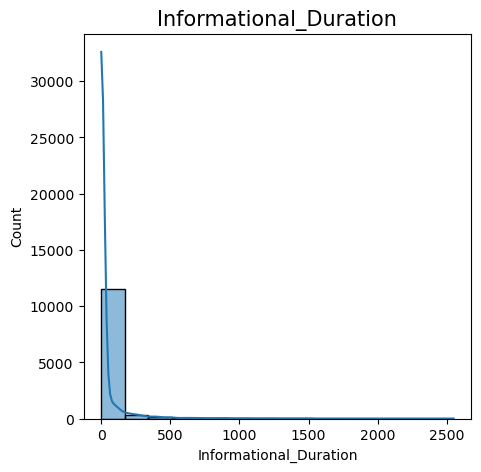

In [245]:
sns.histplot(online.Informational_Duration,kde=True)
plt.title("Informational_Duration", y=1, fontdict={"fontsize": 15})
plt.show()

The above plot shows that the data is not normally distributed. it is skewed on the right.

In [246]:
stats.normaltest(online.Informational_Duration)

NormaltestResult(statistic=16079.869169541158, pvalue=0.0)

We reject the null hypothesis and conclude that the Informational duration is not normally distributed.

#### ProductRelated

In [247]:
online.ProductRelated.describe()

count   12205.00
mean       32.05
std        44.59
min         0.00
25%         8.00
50%        18.00
75%        38.00
max       705.00
Name: ProductRelated, dtype: float64

Text(0.5, 1, 'ProductRelated')

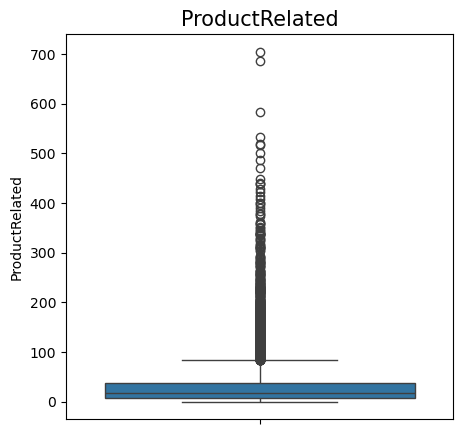

In [250]:
sns.boxplot(y='ProductRelated',data=online)
plt.title('ProductRelated', y=1, fontdict={"fontsize": 15})


The above plot shows a number of out liers.we will proceed to check the pvalue and confirm if the data is normally distributed

In [251]:
stats.normaltest(online.ProductRelated)

NormaltestResult(statistic=11150.087057207267, pvalue=0.0)

The pvalue is less than 5% so we reject the null hypothesis and conclude that the data is not normally distributed.

#### ProductRelated_Duration

In [253]:
online.ProductRelated_Duration.describe()

count   12205.00
mean     1206.98
std      1919.60
min         0.00
25%       193.00
50%       608.94
75%      1477.15
max     63973.52
Name: ProductRelated_Duration, dtype: float64

Alook at the statistics shows that the productRelated duration is not normally distributed given the difference in the 
mean and median which may need to be close or equal for anormal distribution.We will however plot this and prove further.

Text(0.5, 1, 'ProductRelated_Duration')

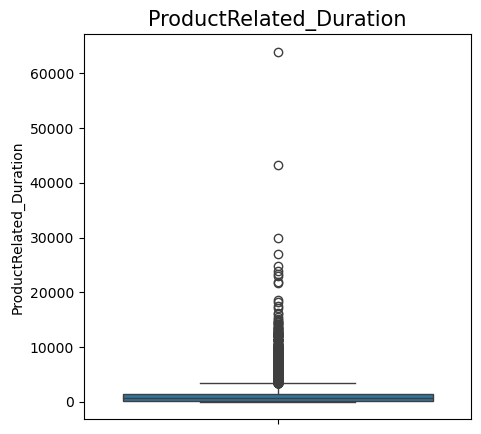

In [254]:
sns.boxplot(y='ProductRelated_Duration',data=online)
plt.title("ProductRelated_Duration", y=1, fontdict={"fontsize": 15})

The above plot shows alot of outliers for this plot, we will go ahead and check the pvalue.

In [255]:
stats.normaltest(online.ProductRelated)

NormaltestResult(statistic=11150.087057207267, pvalue=0.0)

The pvalue, is less than 5%, so just like suspected, this feature is not normally distributed.

#### BounceRates

In [256]:
online.BounceRates.describe()

count   12205.00
mean        0.02
std         0.05
min         0.00
25%         0.00
50%         0.00
75%         0.02
max         0.20
Name: BounceRates, dtype: float64

Text(0.5, 1, 'BounceRates')

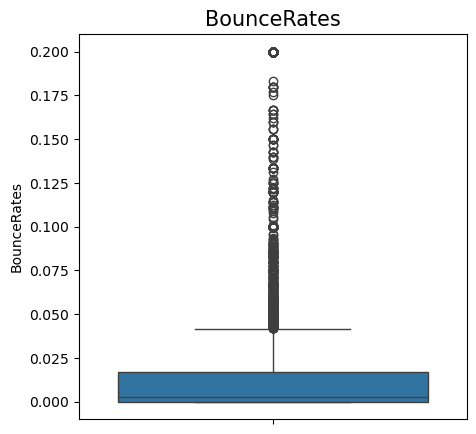

In [257]:
sns.boxplot(y='BounceRates',data=online)
plt.title("BounceRates", y=1, fontdict={"fontsize": 15})

The plot shows that the data is not normally distributed and has outliers.

In [258]:
stats.normaltest(online.BounceRates)

NormaltestResult(statistic=7832.4375636231325, pvalue=0.0)

The bounce rates are not normally distributed.

#### ExitRates

In [259]:
online.ExitRates.describe()

count   12205.00
mean        0.04
std         0.05
min         0.00
25%         0.01
50%         0.03
75%         0.05
max         0.20
Name: ExitRates, dtype: float64

Text(0.5, 1, 'ExitRates')

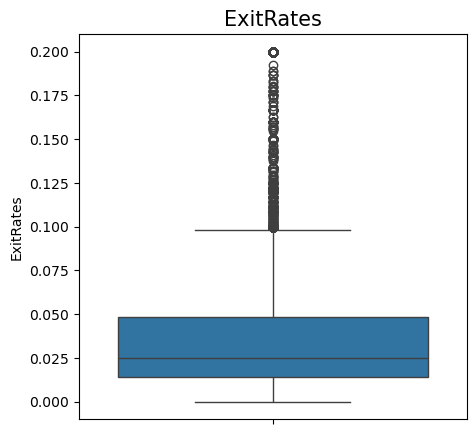

In [260]:
sns.boxplot(y='ExitRates',data=online)
plt.title("ExitRates", y=1, fontdict={"fontsize": 15})

In [261]:
stats.normaltest(online.ExitRates)

NormaltestResult(statistic=5341.715792850626, pvalue=0.0)

Exit rates are not normally distributed.

#### PageValues 

In [264]:
online.PageValues.describe()

count   12205.00
mean        5.95
std        18.65
min         0.00
25%         0.00
50%         0.00
75%         0.00
max       361.76
Name: PageValues, dtype: float64

Text(0.5, 1, 'PageValues')

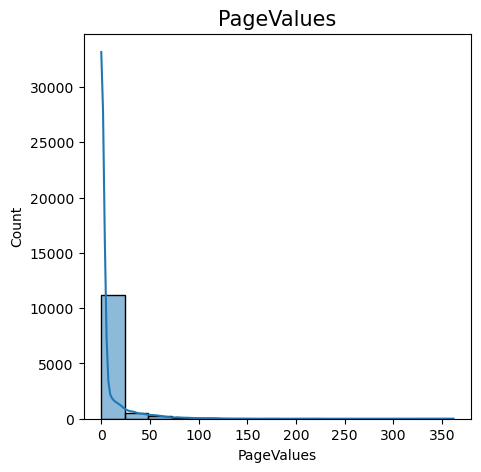

In [266]:
sns.histplot(online.PageValues, kde=True)
plt.title("PageValues", y=1, fontdict={"fontsize": 15})


The page value is not normally distributed.

#### SpecialDay

In [267]:
online.SpecialDay.describe()

count   12205.00
mean        0.06
std         0.20
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         1.00
Name: SpecialDay, dtype: float64

<Axes: xlabel='SpecialDay', ylabel='Count'>

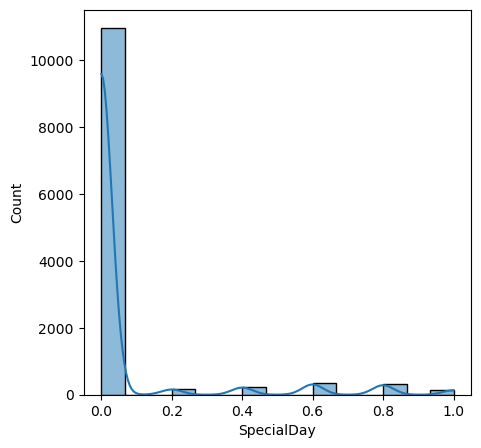

In [270]:
sns.histplot(online.SpecialDay,kde=True)

The feature is not normally distributed

## Q7. Outlier detection using LOF method

In [15]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

In [22]:
LocalOutlierFactor?

In [16]:
numeric=online.drop(['Month','OperatingSystems','Browser','Region','Traffic_Type','VisitorType','Weekend','Revenue'],axis=1)

In [23]:
numeric.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00
3,0,0.00,0,0.00,2,2.67,0.05,0.14,0.00,0.00
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00


In [26]:
numeric.shape

(12205, 11)

Here i created a column called LOF showing the number of outliers

In [152]:
lof = LocalOutlierFactor(n_neighbors=20,contamination='auto')
outliers = lof.fit_predict(numeric)
online["LOF"] = outliers

In [153]:
online.LOF.value_counts()

LOF
 1    11241
-1      964
Name: count, dtype: int64

from the above since outliers are shown with -1, we can see that the data has 964 outliers. 

In [154]:
outliers

array([1, 1, 1, ..., 1, 1, 1])

In [216]:
no_outers= online[outliers != -1]

In [217]:
no_outers.shape

(11241, 19)

The above shows that ouliers have been removed, i will now drop the LOF column because it will not be needed.

In [218]:
no_outers.drop(['LOF'],axis=1,inplace=True)

In [219]:
no_outers.shape

(11241, 18)

### QN8. Perform at least one bivariate analysis for each of the following

#### Chi-square

##### Revenue and month

We will first plot month and Revenue

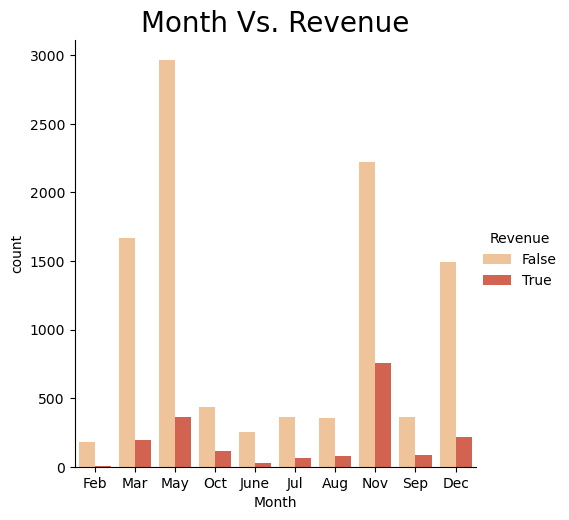

In [96]:
plt.rcParams["figure.figsize"] = (4,5)
sns.catplot(x="Month", kind="count",hue = 'Revenue', palette='OrRd', data=online)
plt.title("Month Vs. Revenue", y=1, fontdict={"fontsize": 20})
plt.show()

The above plot shows the comparison of the month valuable and Revenue. Here we try to look at the bar showing, in which month an online visit turned in to revevue shown in the legend as true and in which month it didnt indicated as false.May had the biggest number of visits but more revenue was recieved from November.

In [124]:
from scipy.stats import chi2_contingency
import researchpy as rp

In [27]:
crosstab, result = rp.crosstab(online['Revenue'], online['Month'], test= "chi-square")

In [38]:
crosstab

Month                                                        
Month     Aug   Dec  Feb  Jul June   Mar   May   Nov  Oct  Sep    All
Revenue                                                              
False     357  1490  178  366  256  1668  2964  2222  434  362  10297
True       76   216    3   66   29   192   365   760  115   86   1908
All       433  1706  181  432  285  1860  3329  2982  549  448  12205

The above table confirms further what the plot is trying to show. may has the highest visits ie 3329,
while November has the highest revenue. Feb is the worst coming out with only 3 visits turning into revenue.

In [371]:
result

,Chi-square test,results
0,Pearson Chi-square ( 9.0) =,376.28
1,p-value =,0.00
2,Cramer's V =,0.18


###### H0 there is no association between Revenue and month
###### H1 there is an association between revenue and month.

Accordingly, we will reject the null hypothesis and conclude that there is an association between 
Revenue and the month of visit at 5% siginificancy level.
And as indicated by cramer's v result, we see a perfect association.


#### Correlation analysis for numerical and categorical with heatmap

#### Numeric columns

In [118]:
corr_numeric=online[["Administrative","Administrative_Duration"]].corr()

In [119]:
corr_numeric

,Administrative,Administrative_Duration
Administrative,1.00,0.60
Administrative_Duration,0.60,1.00


Text(0.5, 1.0, 'Heatmap showing Correlation Between Numerical Features')

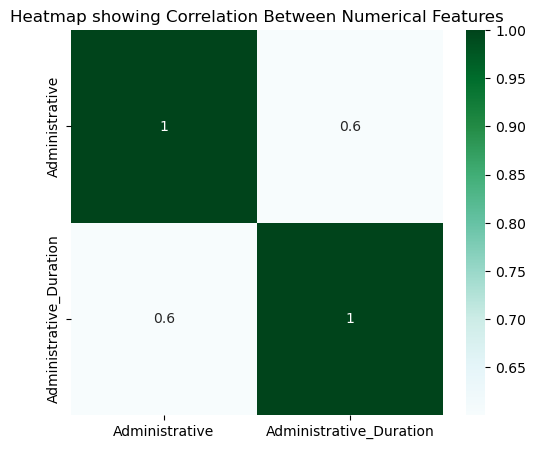

In [393]:
plt.rcParams["figure.figsize"] = (6,5)
sns.heatmap(corr_numeric, cmap="BuGn", annot=True)
plt.title("Heatmap showing Correlation Between Numerical Features")


From above, we see that,Administrative and Administrative duration are fairly correlated.

#### Categorical

In [121]:
col_cat=["Region","VisitorType"]

In [122]:
def cramers_V(var1,var2) :
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None)) # Cross table building
  stat = chi2_contingency(crosstab)[0] # Keeping of the test statistic of the Chi2 test
  obs = np.sum(crosstab) # Number of observations
  mini = min(crosstab.shape)-1 # Take the minimum value between the columns and the rows of the cross table
  return np.sqrt((stat/(obs*mini)))

In [125]:
rows= []

for var1 in online[col_cat]:
  col = []
  for var2 in online[col_cat] :
    cramers =cramers_V(online[var1], online[var2]) # Cramer's V test
    col.append(round(cramers,2)) # Keeping of the rounded value of the Cramer's V  
  rows.append(col)
  
cramers_results = np.array(rows)
Online_cat = pd.DataFrame(cramers_results, columns = online[col_cat].columns, index =online[col_cat].columns)

In [126]:
Online_cat

,Region,VisitorType
Region,1.00,0.17
VisitorType,0.17,1.00


Text(0.5, 1.0, 'Heatmap showing Correlation Between Categorical Features')

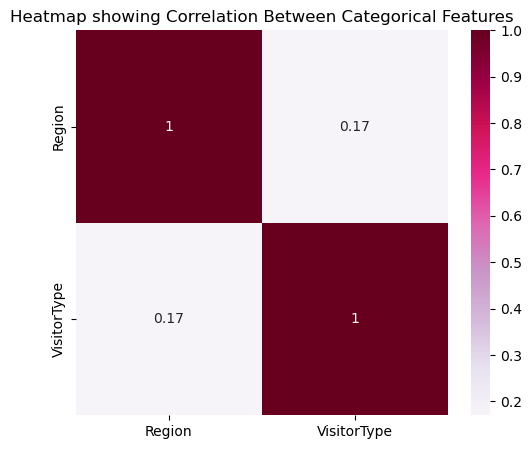

In [399]:
plt.rcParams["figure.figsize"] = (6,5)
sns.heatmap(Online_cat, cmap="PuRd", annot=True)
plt.title("Heatmap showing Correlation Between Categorical Features")


The correlation between the visitor type and region is not strong.

In [128]:
online[["OperatingSystems","Browser","Region","Weekend","Traffic_Type"]]= online[["OperatingSystems","Browser","Region","Weekend","Traffic_Type"]].astype(object)



I just needed to make categorical as objects so that it is easy for me to select out the numericals for coding and collinerity

In [220]:
no_outers

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,VisitorType,Weekend,Revenue,Traffic_Type
0,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,1,1,1,Returning_Visitor,False,False,1
1,0,0.00,0,0.00,2,64.00,0.00,0.10,0.00,0.00,Feb,2,2,1,Returning_Visitor,False,False,2
2,0,0.00,0,0.00,1,0.00,0.20,0.20,0.00,0.00,Feb,4,1,9,Returning_Visitor,False,False,3
4,0,0.00,0,0.00,10,627.50,0.02,0.05,0.00,0.00,Feb,3,3,1,Returning_Visitor,True,False,4
5,0,0.00,0,0.00,19,154.22,0.02,0.02,0.00,0.00,Feb,2,2,1,Returning_Visitor,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.00,0,0.00,53,1783.79,0.01,0.03,12.24,0.00,Dec,4,6,1,Returning_Visitor,True,False,1
12326,0,0.00,0,0.00,5,465.75,0.00,0.02,0.00,0.00,Nov,3,2,1,Returning_Visitor,True,False,other
12327,0,0.00,0,0.00,6,184.25,0.08,0.09,0.00,0.00,Nov,3,2,1,Returning_Visitor,True,False,other
12328,4,75.00,0,0.00,15,346.00,0.00,0.02,0.00,0.00,Nov,2,2,3,Returning_Visitor,False,False,other


In [222]:
Num_no_outers= no_outers.drop(['Month','OperatingSystems','Browser','Region','VisitorType','Weekend','Revenue','Traffic_Type'], axis=1)

In [223]:
Num_no_outers.shape

(11241, 10)

In [224]:
Num_no_outers.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
dtype: object

In [225]:
online_corr= Num_no_outers.corr()

## Checking for collinearity

In [226]:
online_corr

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay
Administrative,1.00,0.62,0.38,0.25,0.42,0.37,-0.22,-0.32,0.16,-0.10
Administrative_Duration,0.62,1.00,0.27,0.16,0.24,0.25,-0.15,-0.23,0.13,-0.08
Informational,0.38,0.27,1.00,0.62,0.35,0.35,-0.11,-0.16,0.11,-0.05
Informational_Duration,0.25,0.16,0.62,1.00,0.22,0.23,-0.07,-0.11,0.08,-0.04
ProductRelated,0.42,0.24,0.35,0.22,1.00,0.87,-0.20,-0.30,0.10,-0.02
ProductRelated_Duration,0.37,0.25,0.35,0.23,0.87,1.00,-0.20,-0.28,0.10,-0.03
BounceRates,-0.22,-0.15,-0.11,-0.07,-0.20,-0.20,1.00,0.90,-0.12,0.07
ExitRates,-0.32,-0.23,-0.16,-0.11,-0.30,-0.28,0.90,1.00,-0.18,0.10
PageValues,0.16,0.13,0.11,0.08,0.10,0.10,-0.12,-0.18,1.00,-0.06
SpecialDay,-0.10,-0.08,-0.05,-0.04,-0.02,-0.03,0.07,0.10,-0.06,1.00


Text(0.5, 1.0, 'Correlation Between Features')

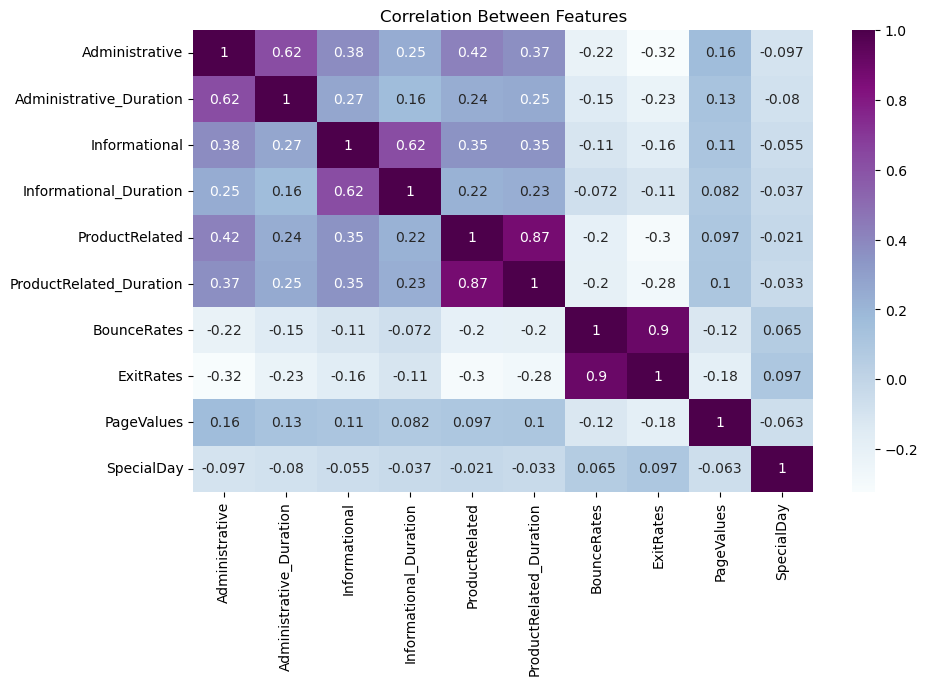

In [227]:
plt.rcParams["figure.figsize"] = (10,6)
sns.heatmap(online_corr, cmap="BuPu", annot=True)
plt.title("Correlation Between Features")


As seen above, the darker places are highly correlated. ie exitrates and bounce rates at 90% and 
productrelated and productrealted_duration. we will define acode on how to remove these.

In [228]:
def remove_corr(df,threshhold):
    corr_cols=set()
    corr_matrix=df.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])> threshhold:
                colname=corr_matrix.columns[i]
                corr_cols.add(colname)
    return corr_cols

In [229]:
remove_corr(Num_no_outers,0.7)

{'ExitRates', 'ProductRelated_Duration'}

Just like expected from the heatmap, Exitrates has been picked for removal since it correlates with Bounce rates, and ProductRelated_duration has been picked since it correlates with Productrelated.

In [230]:
no_outers.drop(['ExitRates', 'ProductRelated_Duration'],axis= 1, inplace=True)

In [231]:
no_outers.shape

(11241, 16)

Now the two columns have been eliminated and our column number has gone down to 8

combining the numerical columns back to our data

In [232]:
online_cat=no_outers.select_dtypes(include=['object'])

In [233]:
online_cat.head(2)

,Month,OperatingSystems,Browser,Region,VisitorType,Weekend,Traffic_Type
0,Feb,1,1,1,Returning_Visitor,False,1
1,Feb,2,2,1,Returning_Visitor,False,2


In [145]:
no_outers.head(2)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,BounceRates,PageValues,SpecialDay
0,0,0.00,0,0.00,1,0.20,0.00,0.00
1,0,0.00,0,0.00,2,0.00,0.00,0.00


In [234]:
no_outers.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,BounceRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,VisitorType,Weekend,Revenue,Traffic_Type
0,0,0.00,0,0.00,1,0.20,0.00,0.00,Feb,1,1,1,Returning_Visitor,False,False,1
1,0,0.00,0,0.00,2,0.00,0.00,0.00,Feb,2,2,1,Returning_Visitor,False,False,2
2,0,0.00,0,0.00,1,0.20,0.00,0.00,Feb,4,1,9,Returning_Visitor,False,False,3
4,0,0.00,0,0.00,10,0.02,0.00,0.00,Feb,3,3,1,Returning_Visitor,True,False,4
5,0,0.00,0,0.00,19,0.02,0.00,0.00,Feb,2,2,1,Returning_Visitor,False,False,3


### Encode the data if there are independent categorical variables

In [249]:
online_encoded = pd.get_dummies(no_outers,columns=["OperatingSystems","Browser","Region","Weekend","Traffic_Type","Month","VisitorType"],drop_first=True)

In [251]:
online_encoded.shape

(11241, 53)

In [237]:
online_encoded.dtypes

Administrative                     int64
Administrative_Duration          float64
Informational                      int64
Informational_Duration           float64
ProductRelated                     int64
BounceRates                      float64
PageValues                       float64
SpecialDay                       float64
Revenue                             bool
OperatingSystems_2                  bool
OperatingSystems_3                  bool
OperatingSystems_4                  bool
OperatingSystems_5                  bool
OperatingSystems_6                  bool
OperatingSystems_7                  bool
OperatingSystems_8                  bool
Browser_2                           bool
Browser_3                           bool
Browser_4                           bool
Browser_5                           bool
Browser_6                           bool
Browser_7                           bool
Browser_8                           bool
Browser_9                           bool
Browser_10      

In [238]:
online_encoded.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,BounceRates,PageValues,SpecialDay,Revenue,OperatingSystems_2,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.00,0,0.00,1,0.20,0.00,0.00,False,False,...,True,False,False,False,False,False,False,False,False,True
1,0,0.00,0,0.00,2,0.00,0.00,0.00,False,True,...,True,False,False,False,False,False,False,False,False,True
2,0,0.00,0,0.00,1,0.20,0.00,0.00,False,False,...,True,False,False,False,False,False,False,False,False,True
4,0,0.00,0,0.00,10,0.02,0.00,0.00,False,False,...,True,False,False,False,False,False,False,False,False,True
5,0,0.00,0,0.00,19,0.02,0.00,0.00,False,True,...,True,False,False,False,False,False,False,False,False,True


### Split the test set

All the independent variables are under the online_encoded dataframe, so we will go ahead and convert revenue into
y since its the traget variable.


In [252]:
x = online_encode.drop(['Revenue'],axis=1)
y = online_encode['Revenue'].map({True: 1, False: 0})

In [253]:
y.head()

0    0
1    0
2    0
4    0
5    0
Name: Revenue, dtype: int64

In [254]:
print(x.shape , y.shape)

(11241, 52) (11241,)


In [255]:
from sklearn.model_selection import train_test_split

In [256]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3,random_state=123)

In [257]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(7868, 52)
(3373, 52)
(7868,)
(3373,)


### Scale the training data and use the same scaler to train the test data

In [258]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = pd.DataFrame(sc.fit_transform(x_train),columns = x.columns)
x_test =pd.DataFrame(sc.transform(x_test),columns = x.columns)

##### Train data without using pca

We try to set the time and observe how long it will take to run a model without pca.

In [259]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import confusion_matrix, classification_report

In [260]:
import time
# Fitting Logistic Regression To the training set 
st=time.time()

LR = LogisticRegression(class_weight='balanced',solver='saga')
LR.fit(x_train, y_train)

en=time.time()

t_time=en-st
print("execution time in sec:",t_time)

execution time in sec: 0.7228684425354004


In [261]:
pred = LR.predict(x_test)

In [262]:
print(classification_report(y_test,pred))
confusion_matrix(y_test,pred)

              precision    recall  f1-score   support

           0       0.96      0.84      0.90      2920
           1       0.43      0.77      0.56       453

    accuracy                           0.83      3373
   macro avg       0.70      0.81      0.73      3373
weighted avg       0.89      0.83      0.85      3373



array([[2463,  457],
       [ 102,  351]], dtype=int64)

We first tried using the model without reduced dimension.
The time spent is 72secs minute and the accuracy is at 083%.
we will apply PCA and run the same model and asses the accuracy and time spent.

### Perform PCA based on out come, recommend if  principle components would be useful

In [263]:
from sklearn.decomposition import PCA

In [264]:
pca = PCA(n_components= 30)

In [265]:
principalComponents = pca.fit_transform(x_train)

In [266]:
principalComponents[:5]

array([[-1.39756725e+00,  8.80816585e-01,  1.21663315e-01,
        -3.57187868e-01,  5.14576915e-01,  2.84255900e+00,
        -2.38029729e-01, -1.86043982e+00, -1.19201924e+00,
        -2.41141262e+00,  2.28150959e+00,  2.36879485e-01,
         3.90532728e+00, -1.36483870e+00, -1.98934794e-01,
        -7.57891948e-01,  2.08423990e+00, -8.95462023e-01,
        -3.30574062e-01, -6.58162671e-01,  9.15067480e-02,
         7.60470875e-02,  3.03339572e-01,  1.25475773e+00,
         2.68820123e-01, -1.41559399e+00, -4.72098408e-01,
        -7.82570484e-01, -1.58118153e+00,  6.35723878e-02],
       [-9.00370121e-01,  4.90047700e-01,  5.06303359e-02,
         6.85122176e-02, -1.26411343e+00, -1.10758219e+00,
        -2.86078431e-01, -2.65323886e-01,  1.58039517e+00,
        -6.62419087e-01, -5.43889578e-01,  2.21124286e-01,
        -3.25320897e-01, -9.63908742e-01,  4.77537392e-02,
         5.15731624e-01, -7.86319055e-02,  5.64962127e-01,
        -2.78284770e-01, -1.58791585e-01,  1.85040051e-

In [267]:
pca.explained_variance_ratio_.sum()

0.7769004649559129

The 30 components chosen can explain 77% of the variance.
So we need to add some more components to increase the explained variance.
let us try to put 15 more components and see, what 45 can do.

In [268]:
pca2 = PCA(n_components= 45)

In [269]:
x_pca_train = pca2.fit_transform(x_train)

In [270]:
pca2.explained_variance_ratio_.sum()

0.9837562725570692

In [271]:
x_pca_train.shape

(7868, 45)

We will use the same instance for the test set

In [272]:
x_pca_test=pca2.transform(x_test)

Now it is evident that the 45 components explain 98% of the variance, so now it is justified to use pca. The remaining 7 features only explain 2%.so we will use running pca with 45 features

### Building classification model and comparing the performance of the theree models, 
### Justify why these metrics are appropriate

###### Classification: Logistic regression

Since we already tried out logistic regression without pca, let us see one with pca and compare the time and accuracy then we will choose which is better.

In [273]:
from sklearn.linear_model import LogisticRegression 

In [673]:
LogisticRegression?

In [274]:
import time
# Fitting Logistic Regression To the training set 
start=time.time()

LR = LogisticRegression(class_weight='balanced',solver='saga')
LR.fit(x_pca_train, y_train)

end=time.time()

total_time=end-start
print("execution time in sec:",total_time)

execution time in sec: 0.44324827194213867


In [275]:
y_pred = LR.predict(x_pca_test)

In [276]:
from sklearn.metrics import confusion_matrix, classification_report,roc_curve, roc_auc_score

In [277]:
print(classification_report(y_test,y_pred))
confusion_matrix(y_test,y_pred)

              precision    recall  f1-score   support

           0       0.96      0.84      0.90      2920
           1       0.43      0.76      0.55       453

    accuracy                           0.83      3373
   macro avg       0.69      0.80      0.72      3373
weighted avg       0.89      0.83      0.85      3373



array([[2465,  455],
       [ 108,  345]], dtype=int64)

I will now try parameter tuning to see how best this model will perform

In [169]:
LogisticRegression?

In [171]:
grid={"C":[0.1, 1, 10, 100], "penalty":["l1","l2"],'class_weight' : ['balanced',None],
        'solver' : ['lbfgs', 'liblinear','sag', 'saga'], }
logreg=LogisticRegression()
logreg_cv=GridSearchCV(logreg,grid,cv=10)
logreg_cv.fit(x_pca_train, y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'class_weight': ['balanced', None],
                         'penalty': ['l1', 'l2'],
                         'solver': ['lbfgs', 'liblinear', 'sag', 'saga']})

In [172]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}
accuracy : 0.8835297259542297


In [176]:
LR_2 = LogisticRegression(C= 1, class_weight= None, penalty= 'l1', solver= 'saga')
LR_2.fit(x_pca_train, y_train)



LogisticRegression(C=1, penalty='l1', solver='saga')

In [177]:
y_pre = LR_2.predict(x_pca_test)

In [178]:
print(classification_report(y_test,y_pre))
confusion_matrix(y_test,y_pre)

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      3064
           1       0.77      0.39      0.52       598

    accuracy                           0.88      3662
   macro avg       0.83      0.68      0.72      3662
weighted avg       0.87      0.88      0.86      3662



array([[2994,   70],
       [ 366,  232]], dtype=int64)

In [199]:
fpr, tpr, thresholds = roc_curve(y_test, y_pre)
roc_auc = roc_auc_score(y_test, y_pre)

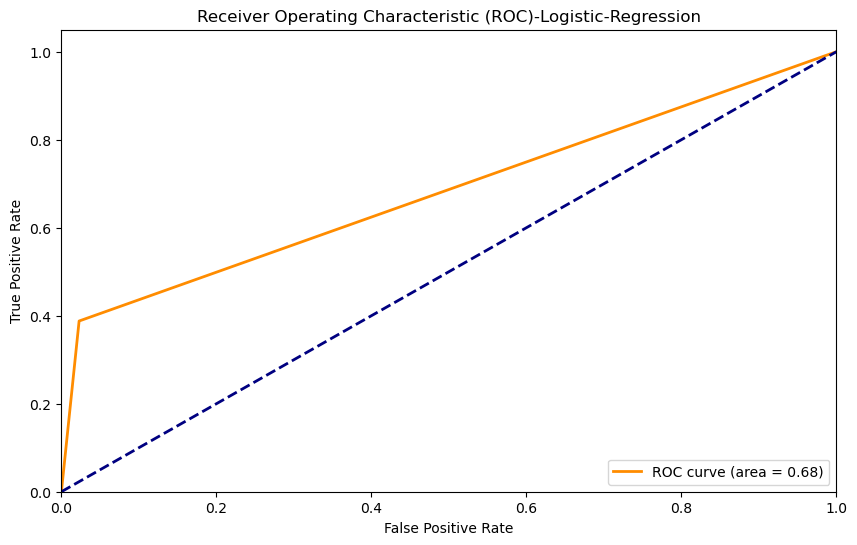

In [200]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)-Logistic-Regression')
plt.legend(loc="lower right")
plt.show()

After tuning, the model has reduced the above results,better than the untuned model on all parameters.
It is however important to note that parameter tuning is not a direct ticket to accuracy or perfection,
sometimes the default parameters may perform better than the tuned parameters.

##### Reccomendation for PCA
Even after reducing the dimension, the accuracy remains at 85% but remember with reduced time, after reducing the dimension, the time taken was 0.57 secs less than the time it took to run the model without reducing the dimension. So in this case, in the interest of time, it is justified to use the PCA for dimension reduction because we still arrive at the same level of accuracy, but will save time.

## KNN

In [58]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

In [699]:
KNeighborsClassifier?

In using KNN, we need to get the right number of Ks. If K is too low, it gets too noisy and creates bias
but if it is too high, it takes long and may also reduce accuracy as the number of k increases. so 
there is need to perform perimeter tunning to get the right number of k.
We use cross-validation to find the accuracy scores. 
We then loop over the values and add the scores to our list.
We pass an instance of the kNN model, along with our data and a number of splits to make. In the code below, we use five splits which means the model will split the data into five equal-sized groups and use 4 to train and 1 to test the result. It will loop through each group and give an accuracy score, which we average to find the best model.

In [278]:
print(x_pca_train.shape)# this is the x_train data that is scaled with reduced dimension
print(x_pca_test.shape) # this is the x_test that is scaled with reduced dimension
print(y_train.shape) 
print(y_test.shape)

(7868, 45)
(3373, 45)
(7868,)
(3373,)


In [279]:
k_values = [i for i in range (1,21,1)]
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, x_pca_train, y_train, cv=5)
    scores.append(np.mean(score))

Below we try to plot the scores in order to analyse the number of k.we took from 1 to 20, and below we used the marker 'o' so that it is easy to identify the number of ks.

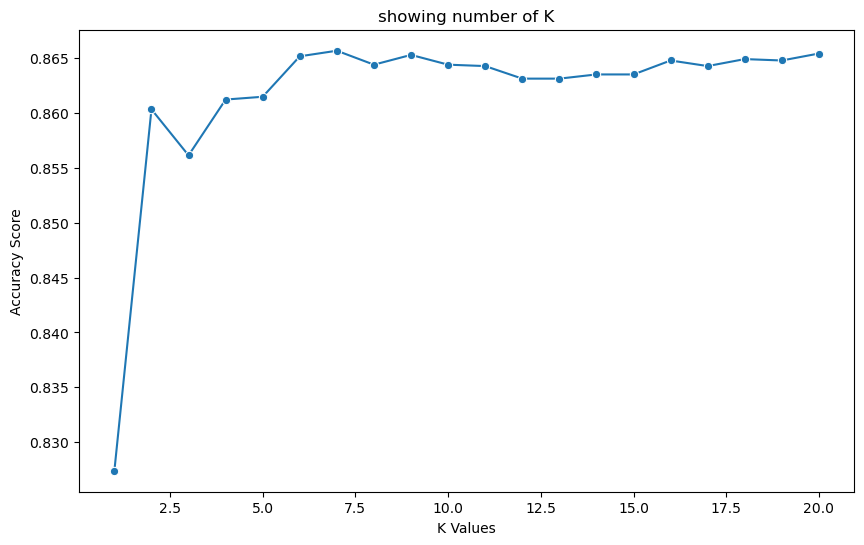

In [280]:
sns.lineplot(x = k_values, y = scores, marker = 'o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")
plt.title("showing number of K")
plt.show()

From the above plot, we see 2 as the best number of k. 



In [281]:
scores

[0.8274024577709458,
 0.8603208042967774,
 0.8561272619029345,
 0.8612110657045392,
 0.8614650337533553,
 0.8651502361563583,
 0.8656584953685567,
 0.8643875242234952,
 0.8652773009594078,
 0.8643873626662121,
 0.8642601363058798,
 0.8631165530784337,
 0.8631163915211507,
 0.8634981513807898,
 0.8634978282662239,
 0.8647687186326438,
 0.8642602978631626,
 0.8648960257716178,
 0.8647687994112854,
 0.8654042849838159]

We will plot the model using the number of ks that we got which is 2.
we will first  Ensure the target variable is binary and integer type

In [282]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(x_pca_train, y_train)


KNeighborsClassifier(n_neighbors=2)

In [283]:
y_predict= knn.predict(x_pca_test)

In [284]:
print(classification_report(y_test,y_predict))
confusion_matrix(y_test,y_predict)

              precision    recall  f1-score   support

           0       0.88      0.99      0.93      2920
           1       0.65      0.17      0.27       453

    accuracy                           0.88      3373
   macro avg       0.77      0.58      0.60      3373
weighted avg       0.85      0.88      0.84      3373



array([[2878,   42],
       [ 375,   78]], dtype=int64)

In [285]:
fpr2, tpr2, thresholds = roc_curve(y_test, y_predict)
roc_auc2 = roc_auc_score(y_test, y_predict)

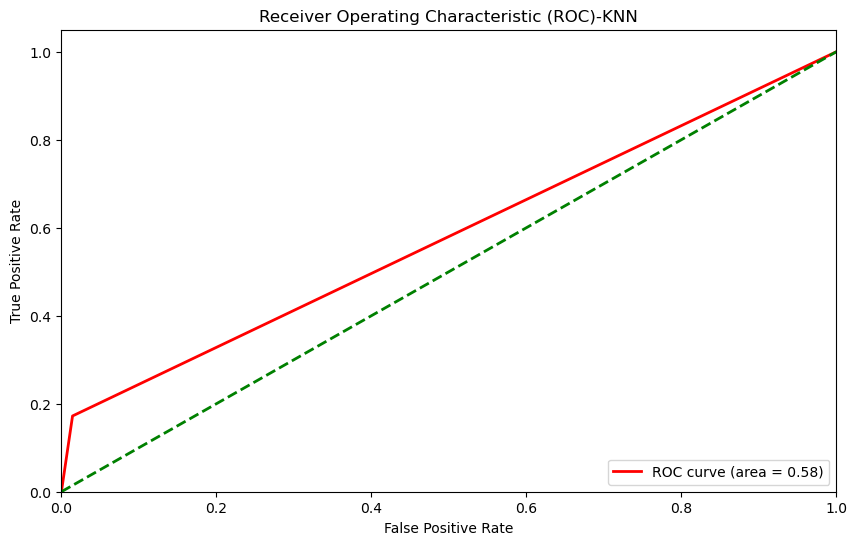

In [286]:
plt.figure()
plt.plot(fpr2, tpr2, color='red', lw=2, label='ROC curve (area = %0.2f)' % roc_auc2)
plt.plot([0, 1], [0, 1], color='green', lw=2,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)-KNN')
plt.legend(loc="lower right")
plt.show()

With Knn, the accuracy is also at 85% just like logistic regression.
but logistic regression has a higher precision at 95 compared to knn at 86, Knn however has a higher recall. Logistic regression also has a higher ROC

#### Random Forest

A random forest model is a stack of multiple decision trees and by combining the results of each decision tree we can change accuracy. Based on this simple explanation of the random forest model there are multiple hyperparameters that we can tune while loading an instance of the random forest model which helps us to prune overfitting.
It should also be remembered that a random forest can run without tuning these features because there are some default values are always pre asigned to the parameters, so we need to tune them to our benefit and get the best model.

In [287]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn import metrics



In [86]:
model1= RandomForestClassifier(class_weight='balanced')
model1.fit(x_train,y_train)
print('Train Accuracy:',
      metrics.accuracy_score(y_train,
                             model1.predict(x_train))*100)

print('Test Accuracy:',
      metrics.accuracy_score(y_test,
                             model1.predict(x_test))*100)

Train Accuracy: 99.96488353037574
Test Accuracy: 88.9404696886947


The above shows that the training set is performing better than the test set which may imply over fitting.
so we will tune the parameters to see if we can come up with a better model that will give us a good performance on the test set.

In [79]:
GridSearchCV?

In [81]:
param_grid = {   "criterion":['gini',"entropy"],
    'n_estimators': [25, 50, 100, 150], 
    'max_features': ['sqrt', 'log2', None], 
    'max_depth': [3,10,12,14,16], 
    'max_leaf_nodes': [3, 6, 9], 
} 

model = GridSearchCV(RandomForestClassifier(random_state=0, n_jobs=-1), param_grid,cv=4)
model.fit(x_train,y_train)
print(model.best_estimator_)

RandomForestClassifier(max_depth=10, max_features=None, max_leaf_nodes=9,
                       n_jobs=-1, random_state=0)


below i will plot the model with the best parameters from the grid.

In [292]:
model_grid = RandomForestClassifier(max_depth=10, 
                                    max_features=None, 
                                    max_leaf_nodes=9, 
                                    n_estimators=100,
                                    random_state=0,
                                    class_weight='balanced',
                                    n_jobs=-1) 
model_grid.fit(x_train, y_train) 
y_pred_grid = model.predict(x_test) 
print(classification_report(y_pred_grid, y_test)) 
confusion_matrix(y_pred_grid, y_test)

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2966
           1       0.62      0.69      0.65       407

    accuracy                           0.91      3373
   macro avg       0.79      0.81      0.80      3373
weighted avg       0.92      0.91      0.91      3373



array([[2792,  174],
       [ 128,  279]], dtype=int64)

The model has given us some good accuracy and high performance on all parameters, so we
will now go ahead and compare performance with the test set.

In [91]:
print('Train Accuracy:',
      metrics.accuracy_score(y_train,
                             model_grid.predict(x_train))*100)

print('Test Accuracy:',
      metrics.accuracy_score(y_test,
                             model_grid.predict(x_test))*100)

Train Accuracy: 85.34472667681142
Test Accuracy: 85.17203713817587


In the code above, we can see that after parameter tunning,
I managed to get a good rating for the test score with almost the same accuracy like the train set,
hence combating over fitting.

In [194]:
fpr3, tpr3, thresholds = roc_curve(y_pred_grid, y_test)
roc_auc3 = roc_auc_score(y_pred_grid, y_test)

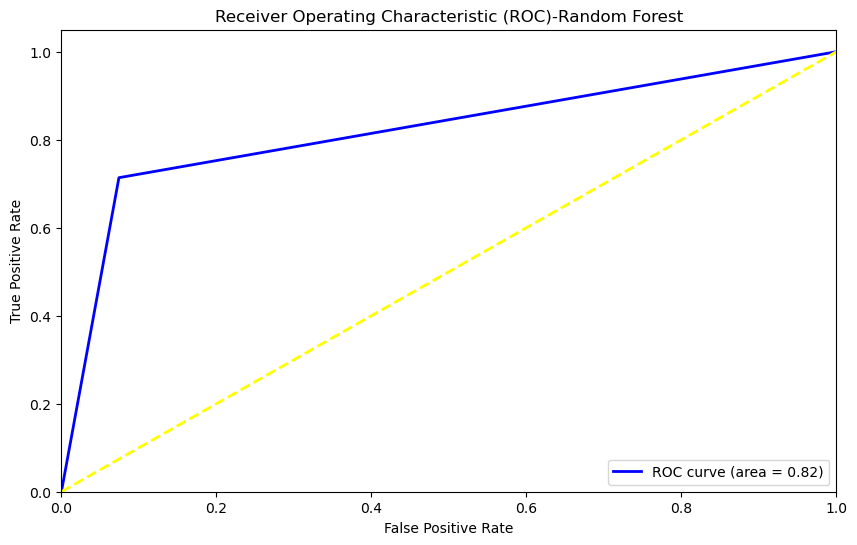

In [196]:
plt.figure()
plt.plot(fpr3, tpr3, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc3)
plt.plot([0, 1], [0, 1], color='yellow', lw=2,linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)-Random Forest')
plt.legend(loc="lower right")
plt.show()

#### Conclusion:
In conclusion however, I will recommend the random forest as the best model for this prediction. After a Grid search, I came up with good parameters that got a fairly good model. It should be noted that parameter tuning may not always give the best results as sometimes the default metrics may be better. It should also be noted that random forest is easily prone to over fitting and is time consuming. But all said, its generally a good model.
